# 02 - Preprocessing and Feature Engineering Report

This report section focuses on the image-processing steps that help panorama stitching become more stable. We start from image representation and basic operators, then end with a configurable preprocessing pipeline that we can run on a single image, a chosen scene, or the full dataset.

## 1. Setup and Data Loading

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import glob
import os


def show_images(images, titles, figsize=(15, 5), color_spaces=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    if color_spaces is None:
        color_spaces = ["rgb"] * n
    elif isinstance(color_spaces, str):
        color_spaces = [color_spaces] * n

    for i, (img, title) in enumerate(zip(images, titles)):
        if img.ndim == 2:
            axes[i].imshow(img, cmap="gray")
        else:
            color_space = color_spaces[i] if i < len(color_spaces) else "rgb"
            if color_space == "bgr":
                display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            elif color_space == "rgb":
                display_img = img
            else:
                raise ValueError(f"Unsupported color_space: {color_space}")
            axes[i].imshow(display_img)
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


image_files = sorted(glob.glob("../data/raw/scene_01/*.jpg"))
if image_files:
    img_bgr = cv2.imread(image_files[0])
else:
    print("No image found, please adjust the sample path.")
    img_bgr = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)

img_bgr = cv2.resize(img_bgr, (600, 400))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image shape:", img_bgr.shape)


Image shape: (400, 600, 3)


## 2. Image Representation, Channels, and Color Spaces

OpenCV loads color images in **BGR** order, while Matplotlib expects **RGB**. If we forget that conversion, the colors look wrong even though the pixels are still valid. For feature extraction we normally reduce the image to grayscale, but color spaces like LAB are also useful when we want to enhance local contrast more carefully.

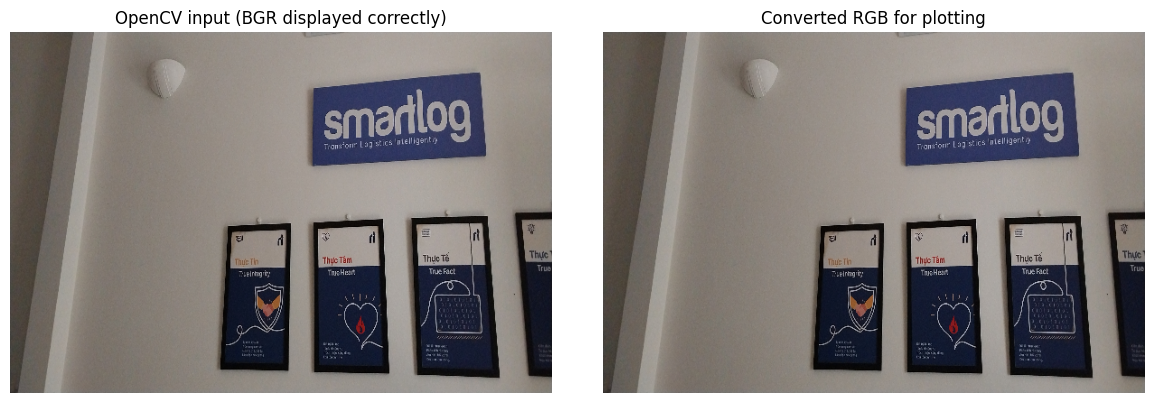

In [2]:
show_images(
    [img_bgr, img_rgb],
    ["OpenCV input (BGR displayed correctly)", "Converted RGB for plotting"],
    figsize=(12, 4),
    color_spaces=["bgr", "rgb"],
)


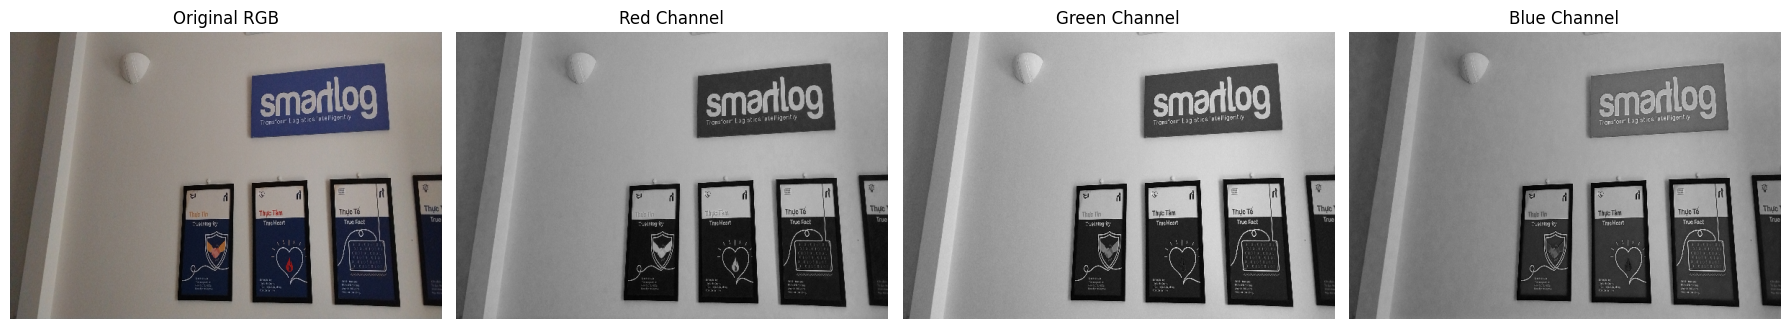

In [3]:
# --- 1.1 Show RGB Channels ---
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

show_images(
    [img_rgb, R, G, B],
    ["Original RGB", "Red Channel", "Green Channel", "Blue Channel"],
    figsize=(18, 5),
    color_spaces=["rgb", "rgb", "rgb", "rgb"],
)


Max difference between scratch and OpenCV: 1


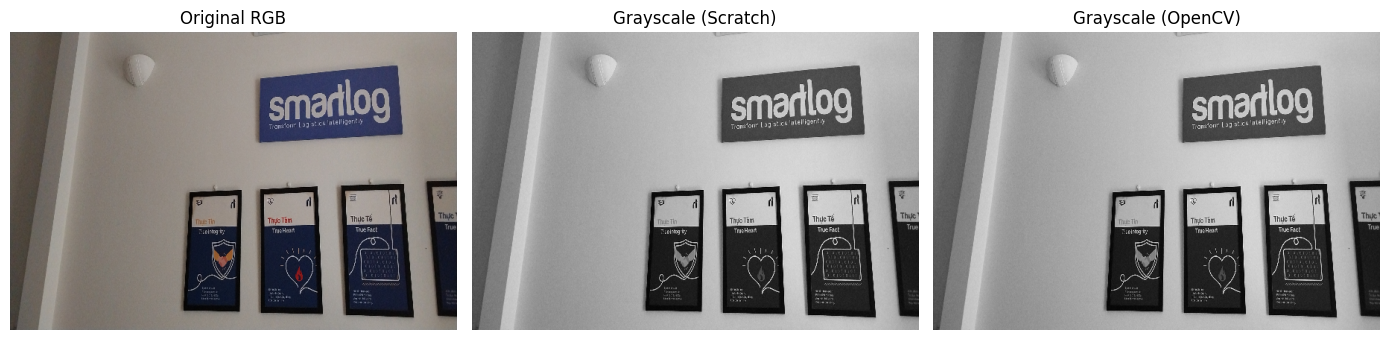

In [4]:
# --- 1.2 Grayscale Conversion FROM SCRATCH ---
# Standard BT.601 luminance: Y = 0.299*R + 0.587*G + 0.114*B
def rgb_to_grayscale_scratch(img_rgb):
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    gray = np.dot(img_rgb[..., :3], weights)
    return gray.astype(np.uint8)


gray_scratch = rgb_to_grayscale_scratch(img_rgb)
gray_cv2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

diff = cv2.absdiff(gray_scratch, gray_cv2)
print("Max difference between scratch and OpenCV:", np.max(diff))

show_images(
    [img_rgb, gray_scratch, gray_cv2],
    ["Original RGB", "Grayscale (Scratch)", "Grayscale (OpenCV)"],
    figsize=(14, 4),
    color_spaces=["rgb", "gray", "gray"],
)


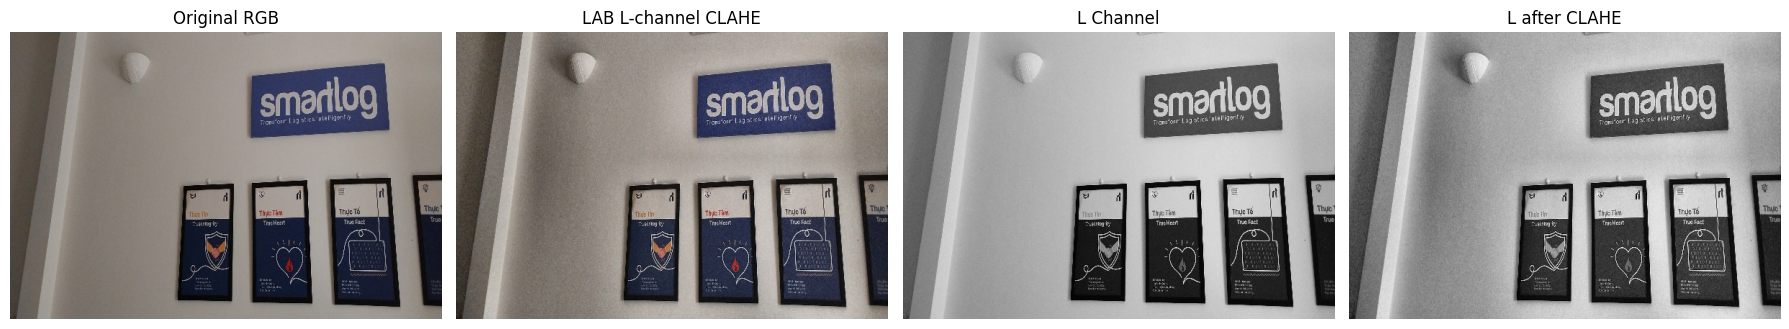

In [5]:
# --- 1.3 LAB Color Space Preview ---
# LAB separates lightness (L) from color channels (A/B), which is handy when we only want
# to boost local contrast without distorting colors too aggressively.
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, A, B_lab = cv2.split(img_lab)

lab_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L_boosted = lab_clahe.apply(L)
img_lab_boosted = cv2.merge([L_boosted, A, B_lab])
img_lab_boosted_rgb = cv2.cvtColor(img_lab_boosted, cv2.COLOR_LAB2RGB)

show_images(
    [img_rgb, img_lab_boosted_rgb, L, L_boosted],
    ["Original RGB", "LAB L-channel CLAHE", "L Channel", "L after CLAHE"],
    figsize=(18, 5),
    color_spaces=["rgb", "rgb", "gray", "gray"],
)


## 3. Point Operations and Contrast Enhancement

Point operations update each pixel independently. For low-light or flat images, histogram-based methods can improve contrast before keypoint detection.

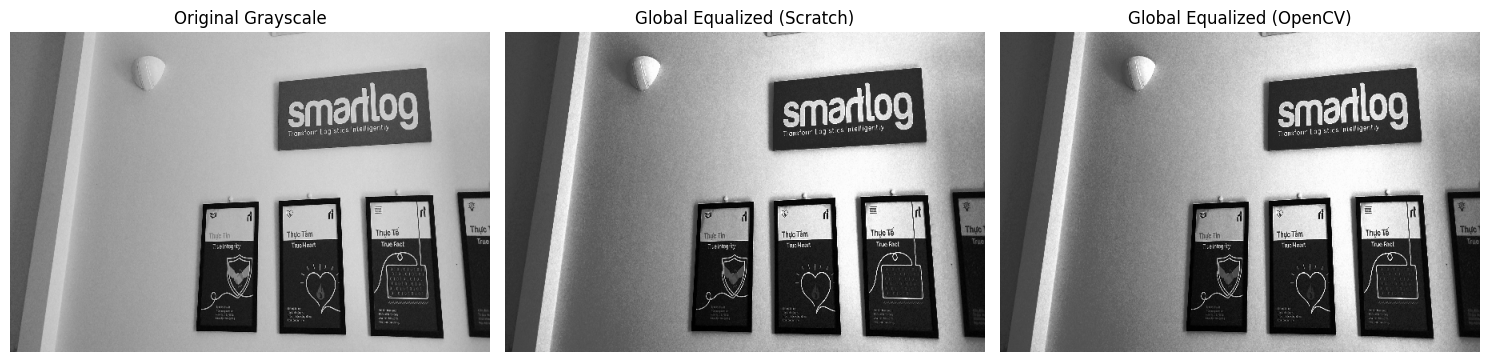

In [6]:
# --- 2.1 Global Histogram Equalization FROM SCRATCH ---
def hist_equalization_scratch(gray_img):
    hist, _ = np.histogram(gray_img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype("uint8")
    return cdf_final[gray_img]


img_eq_scratch = hist_equalization_scratch(gray_scratch)
img_eq_cv2 = cv2.equalizeHist(gray_scratch)

show_images(
    [gray_scratch, img_eq_scratch, img_eq_cv2],
    ["Original Grayscale", "Global Equalized (Scratch)", "Global Equalized (OpenCV)"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


### Why CLAHE is usually better for panorama features
Global equalization can over-stretch already bright regions. CLAHE works tile-by-tile, so we keep more useful local detail for feature detection.

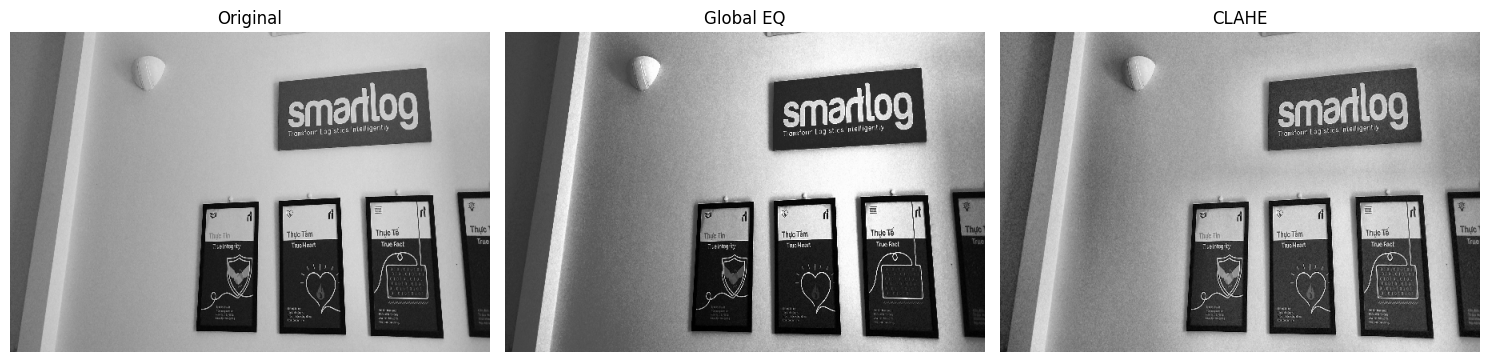

In [7]:
# --- 2.2 CLAHE using OpenCV ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(gray_scratch)

show_images(
    [gray_scratch, img_eq_scratch, img_clahe],
    ["Original", "Global EQ", "CLAHE"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


Estimated gamma: 0.860


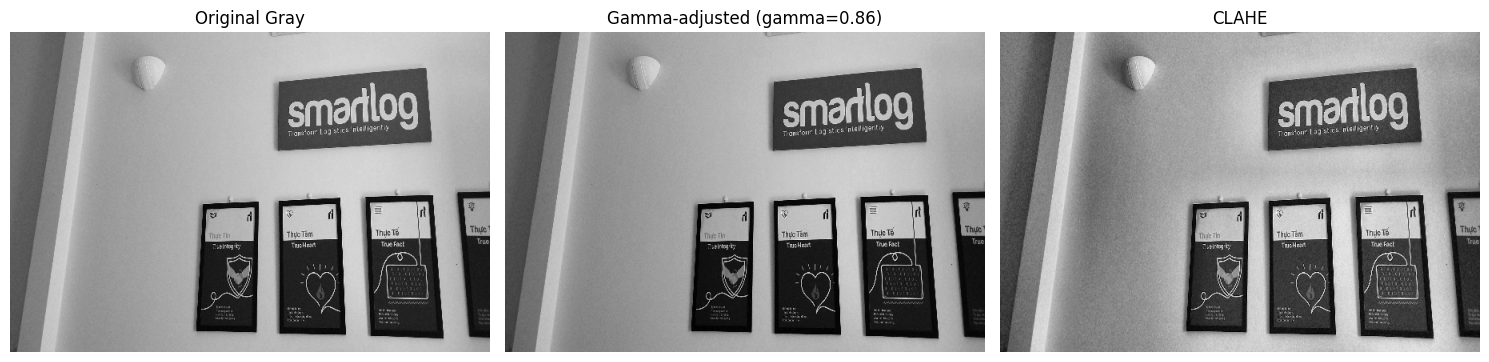

In [8]:
# --- 2.3 Automatic Brightness Normalization ---
def adjust_gamma(gray_img, gamma):
    inv_gamma = 1.0 / gamma
    lut = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(gray_img, lut)


def estimate_auto_gamma(gray_img, target_mean=128.0, gamma_min=0.7, gamma_max=1.5):
    current_mean = float(gray_img.mean())
    if current_mean <= 1.0 or current_mean >= 254.0:
        return 1.0
    current_norm = np.clip(current_mean / 255.0, 1e-4, 1 - 1e-4)
    target_norm = np.clip(target_mean / 255.0, 1e-4, 1 - 1e-4)
    gamma = np.log(target_norm) / np.log(current_norm)
    return float(np.clip(gamma, gamma_min, gamma_max))


auto_gamma = estimate_auto_gamma(gray_scratch)
gray_gamma = adjust_gamma(gray_scratch, auto_gamma)
print(f"Estimated gamma: {auto_gamma:.3f}")

show_images(
    [gray_scratch, gray_gamma, img_clahe],
    ["Original Gray", f"Gamma-adjusted (gamma={auto_gamma:.2f})", "CLAHE"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


## 4. Spatial Filtering, Denoising, and Sharpening

Spatial filters depend on neighboring pixels. For stitching, we usually want a gentle filter that suppresses noise without destroying corners.

Mathematical Gaussian Kernel:
 [[0.014 0.028 0.035 0.028 0.014]
 [0.028 0.055 0.068 0.055 0.028]
 [0.035 0.068 0.085 0.068 0.035]
 [0.028 0.055 0.068 0.055 0.028]
 [0.014 0.028 0.035 0.028 0.014]]


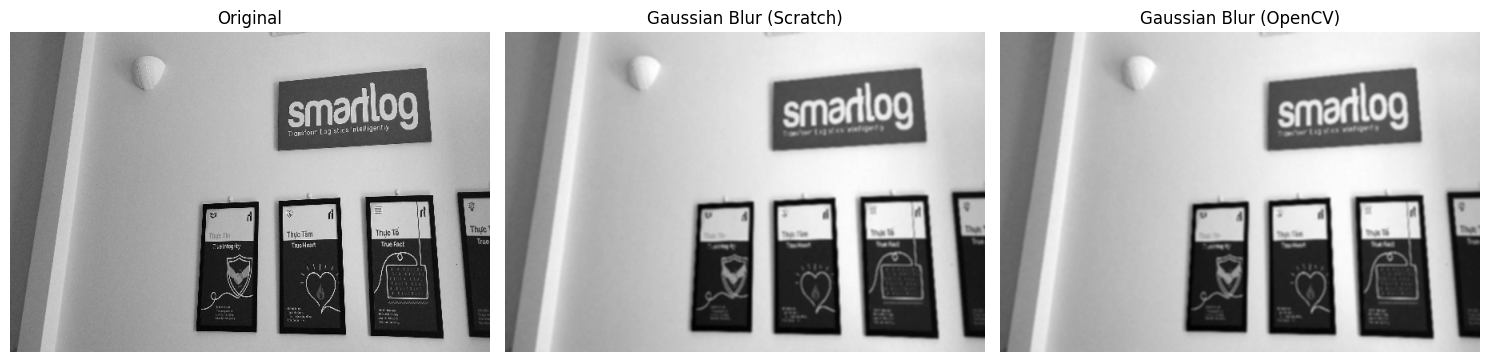

In [9]:
# --- 3.1 Gaussian Kernel and Convolution FROM SCRATCH ---
def create_gaussian_kernel(size, sigma=1.0):
    k = size // 2
    x, y = np.mgrid[-k : k + 1, -k : k + 1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g = normal * np.exp(-((x**2 + y**2) / (2.0 * sigma**2)))
    return g / g.sum()


def convolve_2d_scratch(image, kernel):
    return convolve2d(image, kernel, mode="same", boundary="symm").astype(np.uint8)


kernel_size = 5
sigma = 1.5
gau_kernel = create_gaussian_kernel(kernel_size, sigma)
print("Mathematical Gaussian Kernel:\n", np.round(gau_kernel, 3))

blurred_scratch = convolve_2d_scratch(gray_scratch, gau_kernel)
blurred_cv2 = cv2.GaussianBlur(gray_scratch, (kernel_size, kernel_size), sigmaX=sigma)

show_images(
    [gray_scratch, blurred_scratch, blurred_cv2],
    ["Original", "Gaussian Blur (Scratch)", "Gaussian Blur (OpenCV)"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


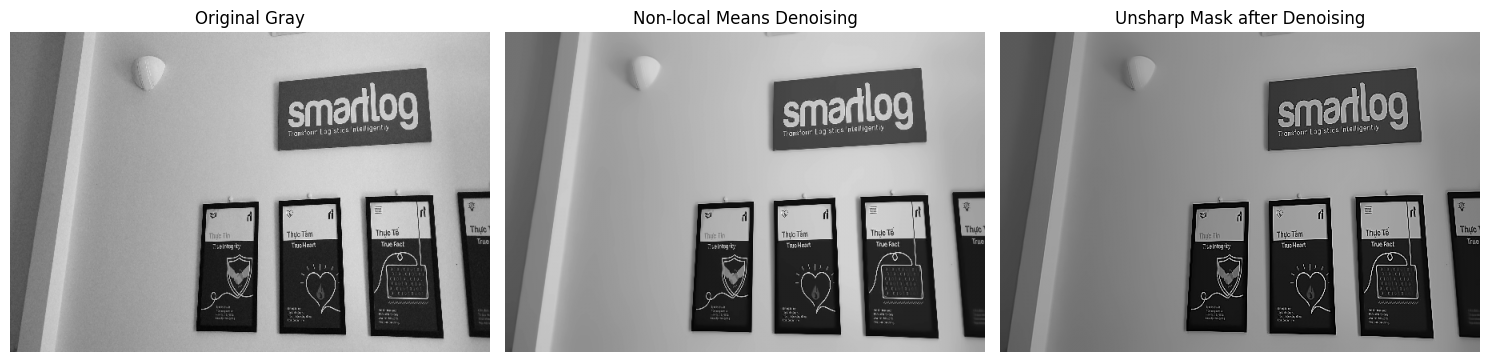

In [10]:
# --- 3.2 Optional Denoising and Unsharp Mask ---
denoised = cv2.fastNlMeansDenoising(gray_scratch, None, h=7, templateWindowSize=7, searchWindowSize=21)

def unsharp_mask(gray_img, sigma=1.0, amount=1.0):
    blurred = cv2.GaussianBlur(gray_img, (0, 0), sigmaX=sigma)
    sharpened = cv2.addWeighted(gray_img, 1.0 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


sharpened = unsharp_mask(denoised, sigma=1.0, amount=0.8)

show_images(
    [gray_scratch, denoised, sharpened],
    ["Original Gray", "Non-local Means Denoising", "Unsharp Mask after Denoising"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


## 5. Morphological Operations

Morphology becomes more meaningful once we create a binary mask or region proposal. That makes it useful for edge cleanup, small-noise removal, and region closing.

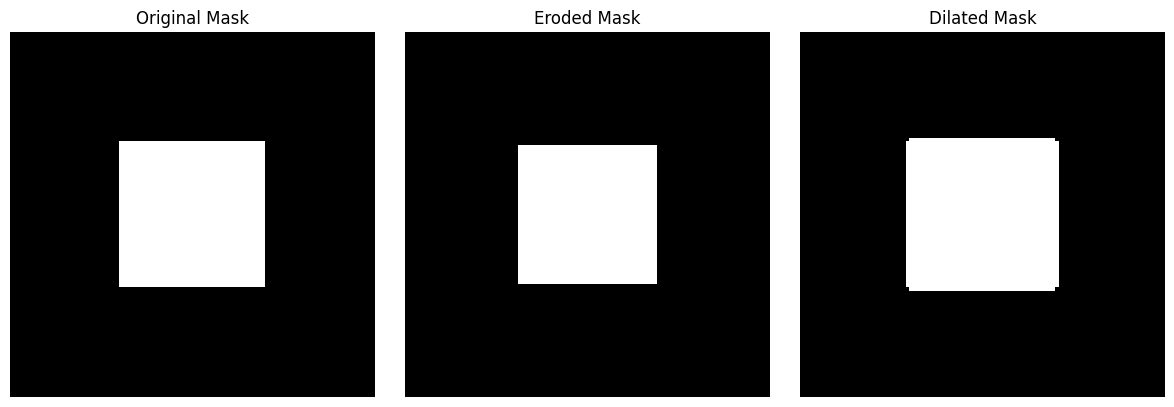

In [11]:
# --- 4.1 Erosion and Dilation FROM SCRATCH on a Synthetic Mask ---
mask = np.zeros((100, 100), dtype=np.uint8)
mask[30:70, 30:70] = 255

struct_elem = np.array(
    [
        [0, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
    ],
    dtype=np.uint8,
)


def erode_scratch(img, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(img, pad, mode="constant", constant_values=0)
    eroded = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i : i + kernel.shape[0], j : j + kernel.shape[1]]
            if np.all(region[kernel == 1] == 255):
                eroded[i, j] = 255
    return eroded


def dilate_scratch(img, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(img, pad, mode="constant", constant_values=0)
    dilated = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i : i + kernel.shape[0], j : j + kernel.shape[1]]
            if np.any(region[kernel == 1] == 255):
                dilated[i, j] = 255
    return dilated


eroded_mask = erode_scratch(mask, struct_elem)
dilated_mask = dilate_scratch(mask, struct_elem)

show_images(
    [mask, eroded_mask, dilated_mask],
    ["Original Mask", "Eroded Mask", "Dilated Mask"],
    figsize=(12, 4),
    color_spaces=["gray", "gray", "gray"],
)


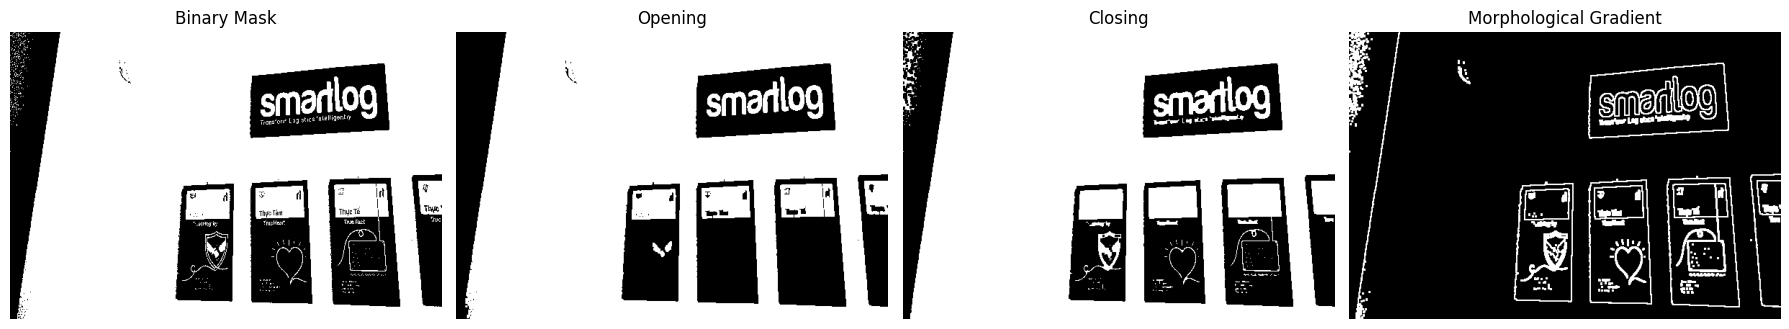

In [12]:
# --- 4.2 Morphology on a Real Binary Mask ---
_, binary = cv2.threshold(gray_scratch, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

show_images(
    [binary, opened, closed, gradient],
    ["Binary Mask", "Opening", "Closing", "Morphological Gradient"],
    figsize=(18, 5),
    color_spaces=["gray", "gray", "gray", "gray"],
)


## 6. Saved Preprocessing Pipeline

For the actual project, we want a compact pipeline that can be reused across many images. The version below keeps the baseline steps from the project and adds a few optional improvements: automatic brightness normalization, optional denoising, and optional sharpening.

In [13]:
def automated_preprocessing_pipeline(
    img_path,
    max_width=800,
    apply_auto_brightness=True,
    apply_denoise=False,
    apply_clahe=True,
    apply_unsharp=False,
):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Image not found at {img_path}")

    # Step 1 - Resize: keep the aspect ratio but reduce resolution so matching runs faster.
    h, w = img_bgr.shape[:2]
    if w > max_width:
        ratio = max_width / float(w)
        img_bgr = cv2.resize(img_bgr, (max_width, int(h * ratio)), interpolation=cv2.INTER_AREA)

    # Step 2 - Grayscale conversion: remove color and keep intensity patterns for feature detection.
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Step 3 - Brightness normalization: pull dark/bright frames closer to a usable exposure range.
    gamma = 1.0
    normalized = gray.copy()
    if apply_auto_brightness:
        gamma = estimate_auto_gamma(gray)
        if abs(gamma - 1.0) > 0.03:
            normalized = adjust_gamma(gray, gamma)

    # Step 4 - Optional denoising: suppress sensor noise in hard low-light frames.
    filtered = normalized.copy()
    if apply_denoise:
        filtered = cv2.fastNlMeansDenoising(filtered, None, h=7, templateWindowSize=7, searchWindowSize=21)

    # Step 5 - Gaussian blur: lightly smooth tiny fluctuations before contrast enhancement.
    blurred = cv2.GaussianBlur(filtered, (3, 3), 0)

    # Step 6 - CLAHE: increase local contrast so weak textures are easier to detect.
    enhanced = blurred.copy()
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(enhanced)

    # Step 7 - Optional unsharp mask: recover a bit of edge crispness in slightly soft frames.
    final_processed = enhanced.copy()
    if apply_unsharp:
        final_processed = unsharp_mask(final_processed, sigma=1.0, amount=0.8)

    meta = {
        "gamma": round(float(gamma), 3),
        "mean_before": round(float(gray.mean()), 2),
        "mean_after": round(float(final_processed.mean()), 2),
    }
    stages = {
        "rgb": img_rgb,
        "gray": gray,
        "normalized": normalized,
        "blurred": blurred,
        "final": final_processed,
    }
    return stages, meta


sample_path = "../data/raw/scene_01/img_001.jpg"
if os.path.exists(sample_path):
    stages, meta = automated_preprocessing_pipeline(
        sample_path,
        apply_auto_brightness=True,
        apply_denoise=False,
        apply_clahe=True,
        apply_unsharp=True,
    )
    print(meta)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.ravel()

    axes[0].imshow(stages["rgb"])
    axes[0].set_title("1. Original RGB\nReference image before preprocessing")
    axes[0].axis("off")

    axes[1].imshow(stages["gray"], cmap="gray")
    axes[1].set_title("2. Grayscale\nKeep intensity, remove color variation")
    axes[1].axis("off")

    axes[2].imshow(stages["normalized"], cmap="gray")
    axes[2].set_title("3. Brightness-normalized\nBring dark/bright frames closer together")
    axes[2].axis("off")

    axes[3].imshow(stages["blurred"], cmap="gray")
    axes[3].set_title("4. Gaussian Blur\nReduce fine-grain noise")
    axes[3].axis("off")

    axes[4].imshow(stages["final"], cmap="gray")
    axes[4].set_title("5. Final Feature-ready Output\nCLAHE + optional sharpening for matching")
    axes[4].axis("off")

    axes[5].axis("off")
    axes[5].text(0.0, 0.8, f"Gamma: {meta['gamma']}", fontsize=12)
    axes[5].text(0.0, 0.6, f"Mean before: {meta['mean_before']}", fontsize=12)
    axes[5].text(0.0, 0.4, f"Mean after: {meta['mean_after']}", fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print(f"Sample path {sample_path} not found. Please adjust the path to a valid image.")


Sample path ../data/raw/scene_01/img_001.jpg not found. Please adjust the path to a valid image.


## 7. Batch Processing Strategy

The notebook explains the preprocessing logic, but the real dataset should be processed with `scripts/apply_preprocessing.py`. The script writes outputs under `data/preprocessing/...` and keeps `data/raw` plus `data/split` untouched.

### Environment
If the `image_recognition` environment is already activated, use `python`. If not, replace `python` with:

```bash
C:/Users/PC/anaconda3/envs/image_recognition/python.exe
```

### Where outputs are saved
- raw dataset default: `data/preprocessing/raw`
- development split: `data/preprocessing/development`
- test split: `data/preprocessing/test`
- failure analysis split: `data/preprocessing/failure_analysis`
- whole split tree: `data/preprocessing/split`

### Run on the full raw dataset
```bash
python scripts/apply_preprocessing.py
python scripts/apply_preprocessing.py --ordered-only
python scripts/apply_preprocessing.py --dry-run
```

### Run on a split
```bash
python scripts/apply_preprocessing.py --split development --ordered-only
python scripts/apply_preprocessing.py --split test --ordered-only
python scripts/apply_preprocessing.py --split failure --ordered-only
python scripts/apply_preprocessing.py --split split --ordered-only
```

### Run on selected scenes
```bash
python scripts/apply_preprocessing.py --scene scene_04 --scene scene_21
python scripts/apply_preprocessing.py --split development --scene scene_01 --scene scene_03 --ordered-only
```

### Run on selected images
```bash
python scripts/apply_preprocessing.py --image scene_04/img_01.jpg --image scene_30/img_03.jpg
python scripts/apply_preprocessing.py --split failure --image scene_04/img_01.jpg
```

### Skip scenes or images
```bash
python scripts/apply_preprocessing.py --skip-scene scene_14 --skip-image scene_29/img_08.jpg
python scripts/apply_preprocessing.py --split split --skip-scene scene_14 --ordered-only
```

### Choose the preprocessing policy
```bash
python scripts/apply_preprocessing.py --profile baseline
python scripts/apply_preprocessing.py --profile enhanced --denoise --unsharp
python scripts/apply_preprocessing.py --profile audit_auto --ordered-only
```

`baseline` keeps the standard resize + Gaussian blur + CLAHE flow.
`enhanced` enables the richer pipeline when combined with options like `--denoise` and `--unsharp`.
`audit_auto` reads `outputs/audit/image_metrics.csv` and adapts preprocessing to audit recommendations.

### Choose what to save
```bash
python scripts/apply_preprocessing.py --output-kind gray
python scripts/apply_preprocessing.py --output-kind color
python scripts/apply_preprocessing.py --output-kind both
```

- `gray`: feature-ready grayscale images in `feature_gray`
- `color`: color-enhanced images in `color_enhanced`
- `both`: save both versions

### Useful control flags
```bash
python scripts/apply_preprocessing.py --ordered-only
python scripts/apply_preprocessing.py --skip-drop-recommended
python scripts/apply_preprocessing.py --overwrite
python scripts/apply_preprocessing.py --output-root data/preprocessing/custom_trial
```

- `--ordered-only`: only preprocess stitch-input images, not reference leftovers
- `--skip-drop-recommended`: ignore images the audit says should be dropped/retaken
- `--overwrite`: replace existing outputs
- `--output-root`: send results to a custom destination

### Typical workflow
```bash
python scripts/apply_preprocessing.py --split development --ordered-only --dry-run
python scripts/apply_preprocessing.py --split development --ordered-only
python scripts/apply_preprocessing.py --split test --ordered-only
python scripts/apply_preprocessing.py --split failure --ordered-only
```

This keeps the split frozen first, then applies the same preprocessing policy to development, test, and failure-analysis scenes.